The following has been adapted from Hailo's DFC Tutorials 1 and 2 (Parsing and Optimizing with DFC). It was run from a docker container setup using Hailo AI SoftwareSuite


In [1]:
# General imports used throughout the tutorial
# file operations
import json
import os

import numpy as np
import tensorflow as tf
from IPython.display import SVG
from matplotlib import patches
from matplotlib import pyplot as plt
from PIL import Image
from tensorflow.python.eager.context import eager_mode

import torchvision as tv
import torch

import cv2

# import the hailo sdk client relevant classes
from hailo_sdk_client import ClientRunner, InferenceContext

%matplotlib inline

IMAGES_TO_VISUALIZE = 5

2025-05-05 02:24:04.095062: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-05 02:24:04.120355: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-05 02:24:04.490386: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
chosen_hw_arch = "hailo8l"

## Model Optimization

In [3]:
def resize_with_letterbox(image_path, target_shape=(1,640,640,3), padding_value=(0, 0, 0)):
    """
    Resizes an image with letterboxing to fit the target size, preserving aspect ratio.
    
    Parameters:
        image_path (str): Path to the input image.
        target_shape (tuple): Target shape in NHWC format (batch_size, target_height, target_width, channels).
        padding_value (tuple): RGB values for padding (default is black padding).
        
    Returns:
        letterboxed_image (ndarray): The resized image with letterboxing.
        scale (float): Scaling ratio applied to the original image.
        pad_top (int): Padding applied to the top.
        pad_left (int): Padding applied to the left.
    """
    # Load the image from the given path
    image = cv2.imread(image_path)
    
    # Check if the image was loaded successfully
    if image is None:
        raise ValueError(f"Error: Unable to load image from path: {image_path}")
    
#     # Convert the image from BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Get the original image dimensions (height, width, channels)
    h, w, c = image.shape
    
    # Extract target height and width from target_shape (NHWC format)
    target_height, target_width = target_shape[1], target_shape[2]
    
    # Calculate the scaling factors for width and height
    scale_x = target_width / w
    scale_y = target_height / h
    
    # Choose the smaller scale factor to preserve the aspect ratio
    scale = min(scale_x, scale_y)
    
    # Calculate the new dimensions based on the scaling factor
    new_w = int(w * scale)
    new_h = int(h * scale)

    # Resize the image to the new dimensions
    resized_image = cv2.resize(image, (new_w, new_h),interpolation=cv2.INTER_LINEAR)
    
    # Create a new image with the target size, filled with the padding value
    letterboxed_image = np.full((target_height, target_width, c), padding_value, dtype=np.uint8)
    
    # Compute the position where the resized image should be placed (padding)
    pad_top = (target_height - new_h) // 2
    pad_left = (target_width - new_w) // 2
    
    # Place the resized image onto the letterbox background
    letterboxed_image[pad_top:pad_top+new_h, pad_left:pad_left+new_w] = resized_image

    
    # Return the letterboxed image, scaling ratio, and padding (top, left)
    return letterboxed_image, scale, pad_top, pad_left

In [4]:
# quantization needs calibration data, use the training data for this
cal_images_path = "../data/visdrone/train/images/" # use training data for calib
cal_images_list = [img_name for img_name in os.listdir(cal_images_path) if os.path.splitext(img_name)[1] == ".jpg"]
dataset_sz = 3000
calib_dataset = np.zeros((dataset_sz, 640, 640, 3))

for idx, img_name in enumerate(sorted(cal_images_list)):
    if idx==dataset_sz:
        break
    imgpth = os.path.join(cal_images_path, img_name)
    img_preproc, _, _, _ = resize_with_letterbox(imgpth, (1,640,640,3))
    calib_dataset[idx, :, :, :] = img_preproc
    
print(f"Calibration dataset size: {calib_dataset.shape}")



Calibration dataset size: (3000, 640, 640, 3)


In [5]:
onnx_model_name = "yolov5sp2_ghost_visdrone"
onnx_path = '/local/shared_with_docker/visdrone/models/best/onnx/yolov5s-p2-ghost.onnx'

runner = ClientRunner(hw_arch=chosen_hw_arch)
hn, npz = runner.translate_onnx_model(
    onnx_path,
    onnx_model_name,
    start_node_names=["/model.0/conv/Conv"],
    end_node_names=["/model.22/m.2/Conv", 
                   "/model.22/m.1/Conv",
                   "/model.22/m.0/Conv"],
    net_input_shapes={"/model.0/conv/Conv": [1, 3, 640, 640]},
)
#save the parsed model
hailo_model_har_name = f"{onnx_model_name}_{str.split(os.path.basename(onnx_path),'.')[0]}_hailo_model_singlecls.har"
runner.save_har(hailo_model_har_name)

#load our parsed HAR from the Parsing Tutorial
assert os.path.isfile(hailo_model_har_name), "Please provide valid path for HAR file"
runner = ClientRunner(har=hailo_model_har_name)
print(f"\n\n{'='*100}\nloaded {hailo_model_har_name}\n{'='*100}\n\n")

alls =  """
normalization1 = normalization([0.0, 0.0, 0.0], [255.0, 255.0, 255.0])
change_output_activation(sigmoid)
model_optimization_config(calibration, batch_size=8, calibset_size=128)
post_quantization_optimization(finetune, policy=enabled, learning_rate=0.00001, epochs=8, batch_size=16, dataset_size=3000)
nms_postprocess("/local/shared_with_docker/visdrone/postprocess_config/yolov5nv6_p2_nms_config.json", yolov5, engine=cpu)
performance_param(compiler_optimization_level=max)
allocator_param(width_splitter_defuse=disabled)

# """
# # nms_postprocess("/local/shared_with_docker/visdrone/postprocess_config/yolov5s_nms_config.json", yolov5, engine=cpu)

runner.load_model_script(alls)
# runner.optimize_full_precision()

runner.optimize(calib_dataset)

model_name = "yolov5sp2_ghost_visdrone_singlecls"
quant_model_har_path = f"{model_name}_quant_model.har"
runner.save_har(quant_model_har_path)
print(f"\n\n{'='*100}\nsaving {quant_model_har_path}\n{'='*100}\n\n")


[info] Translation started on ONNX model yolov5sp2_ghost_visdrone
[info] Restored ONNX model yolov5sp2_ghost_visdrone (completion time: 00:00:00.02)
[info] Extracted ONNXRuntime meta-data for Hailo model (completion time: 00:00:00.10)
[info] NMS structure of yolov5 (or equivalent architecture) was detected. 
[info] Start nodes mapped from original model: 'images': 'yolov5sp2_ghost_visdrone/input_layer1'.
[info] End nodes mapped from original model: '/model.22/m.2/Conv', '/model.22/m.1/Conv', '/model.22/m.0/Conv'.
[info] Translation completed on ONNX model yolov5sp2_ghost_visdrone (completion time: 00:00:00.69)
[info] Saved HAR to: /local/workspace/hailo_virtualenv/lib/python3.10/site-packages/hailo_tutorials/notebooks/yolov5sp2_ghost_visdrone_yolov5s-p2-ghost_hailo_model_singlecls.har


loaded yolov5sp2_ghost_visdrone_yolov5s-p2-ghost_hailo_model_singlecls.har


[info] ParsedPerformanceParam command, setting optimization_level(max=2)
[info] Loading model script commands to yolov5sp2_gh

2025-05-05 01:58:50.015941: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 01:58:50.031777: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 01:58:50.031889: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

[info] Using default optimization level of 2
[info] Model received quantization params from the hn


2025-05-05 01:58:51.170745: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 01:58:51.186140: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 01:58:51.186264: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

[info] MatmulDecompose skipped
[info] Starting Mixed Precision
[info] Model Optimization Algorithm Mixed Precision is done (completion time is 00:00:00.37)
[info] LayerNorm Decomposition skipped
[info] Starting Statistics Collector
[info] Using dataset with 128 entries for calibration


...

187/187 [==============================] - 204s 688ms/step - total_distill_loss: 0.6346 - _distill_loss_yolov5sp2_ghost_visdrone/conv41: 0.0377 - _distill_loss_yolov5sp2_ghost_visdrone/conv48: 0.0449 - _distill_loss_yolov5sp2_ghost_visdrone/conv54: 0.0612 - _distill_loss_yolov5sp2_ghost_visdrone/conv39: 0.2447 - _distill_loss_yolov5sp2_ghost_visdrone/conv46: 0.2461
Epoch 2/8
187/187 [==============================] - 129s 687ms/step - total_distill_loss: 0.5462 - _distill_loss_yolov5sp2_ghost_visdrone/conv41: 0.0340 - _distill_loss_yolov5sp2_ghost_visdrone/conv48: 0.0404 - _distill_loss_yolov5sp2_ghost_visdrone/conv54: 0.0531 - _distill_loss_yolov5sp2_ghost_visdrone/conv39: 0.2081 - _distill_loss_yolov5sp2_ghost_visdrone/conv46: 0.2106
Epoch 3/8
187/187 [==============================] - 129s 688ms/step - total_distill_loss: 0.5332 - _distill_loss_yolov5sp2_ghost_visdrone/conv41: 0.0328 - _distill_loss_yolov5sp2_ghost_visdrone/conv48: 0.0393 - _distill_loss_yolov5sp2_ghost_visdrone/con

2025-05-05 02:18:14.528697: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 02:18:14.553278: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 02:18:14.553429: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

[info] Starting Layer Noise Analysis


Full Quant Analysis:  50%|█████████████████████████████████████████████████████████████████████▌                                                                     | 1/2 [00:00<00:00,  1.09iterations/s]2025-05-05 02:18:22.594600: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-05-05 02:18:22.692966: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [8,640,640,3]
	 [[{{node Placeholder/_0}}]]
2025-05-05 02:19:53.148599: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8906
202

[info] Model Optimization Algorithm Layer Noise Analysis is done (completion time is 00:01:35.56)
[info] Model Optimization is done
[info] Saved HAR to: /local/workspace/hailo_virtualenv/lib/python3.10/site-packages/hailo_tutorials/notebooks/yolov5sp2_ghost_visdrone_singlecls_quant_model.har


saving yolov5sp2_ghost_visdrone_singlecls_quant_model.har




In [22]:
onnx_model_name = "yolov5n_visdrone"
onnx_path = '/local/shared_with_docker/visdrone/models/best/onnx/exp_1_yolov5nv6_singlecls.onnx'

runner = ClientRunner(hw_arch=chosen_hw_arch)
hn, npz = runner.translate_onnx_model(
    onnx_path,
    onnx_model_name,
    start_node_names=["/model.0/conv/Conv"],
    end_node_names=["/model.24/m.2/Conv", 
                   "/model.24/m.1/Conv",
                   "/model.24/m.0/Conv"],
    net_input_shapes={"/model.0/conv/Conv": [1, 3, 640, 640]},
)
#save the parsed model
hailo_model_har_name = f"{onnx_model_name}_{str.split(os.path.basename(onnx_path),'.')[0]}_hailo_model_singlecls.har"
runner.save_har(hailo_model_har_name)

#load our parsed HAR from the Parsing Tutorial
assert os.path.isfile(hailo_model_har_name), "Please provide valid path for HAR file"
runner = ClientRunner(har=hailo_model_har_name)
print(f"\n\n{'='*100}\nloaded {hailo_model_har_name}\n{'='*100}\n\n")

alls =  """
normalization1 = normalization([0.0, 0.0, 0.0], [255.0, 255.0, 255.0])
change_output_activation(sigmoid)
model_optimization_config(calibration, batch_size=8, calibset_size=256)
post_quantization_optimization(finetune, policy=enabled, learning_rate=0.00001, epochs=8, batch_size=16, dataset_size=3000)
nms_postprocess("/local/shared_with_docker/visdrone/postprocess_config/yolov5nv6_nms_config_custom.json", yolov5, engine=cpu)
performance_param(compiler_optimization_level=max)
allocator_param(width_splitter_defuse=disabled)

"""
# nms_postprocess("/local/shared_with_docker/visdrone/postprocess_config/yolov5s_nms_config.json", yolov5, engine=cpu)

runner.load_model_script(alls)
# runner.optimize_full_precision()

runner.optimize(calib_dataset)

model_name = "yolov5p2SPPF_visdrone_singlecls"
quant_model_har_path = f"{model_name}_quant_model.har"
runner.save_har(quant_model_har_path)
print(f"\n\n{'='*100}\nsaving {quant_model_har_path}\n{'='*100}\n\n")


[info] Translation started on ONNX model yolov5n_visdrone
[info] Restored ONNX model yolov5n_visdrone (completion time: 00:00:00.02)
[info] Extracted ONNXRuntime meta-data for Hailo model (completion time: 00:00:00.10)
[info] NMS structure of yolov5 (or equivalent architecture) was detected. 
[info] Start nodes mapped from original model: 'images': 'yolov5n_visdrone/input_layer1'.
[info] End nodes mapped from original model: '/model.24/m.2/Conv', '/model.24/m.1/Conv', '/model.24/m.0/Conv'.
[info] Translation completed on ONNX model yolov5n_visdrone (completion time: 00:00:00.93)
[info] Saved HAR to: /local/workspace/hailo_virtualenv/lib/python3.10/site-packages/hailo_tutorials/notebooks/yolov5n_visdrone_exp_1_yolov5nv6_singlecls_hailo_model_singlecls.har


loaded yolov5n_visdrone_exp_1_yolov5nv6_singlecls_hailo_model_singlecls.har


[info] ParsedPerformanceParam command, setting optimization_level(max=2)
[info] Loading model script commands to yolov5n_visdrone from string
[info] Parsed

2025-04-25 05:02:11.026532: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:1279] could not retrieve CUDA device count: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-04-25 05:02:11.293670: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:1279] could not retrieve CUDA device count: CUDA_ERROR_NOT_INITIALIZED: initialization error


[info] MatmulDecompose skipped
[info] Starting Mixed Precision
[info] Model Optimization Algorithm Mixed Precision is done (completion time is 00:00:00.26)
[info] LayerNorm Decomposition skipped
[info] Starting Statistics Collector
[info] Using dataset with 256 entries for calibration


Calibration:   0%|                                                                                                                                                            | 0/256 [00:00<?, ?entries/s]2025-04-25 05:02:16.666334: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-04-25 05:02:16.708138: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [8,640,640,3]
	 [[{{node Placeholder/_0}}]]
Calibration:   3%|████▋                                                                                                  

Calibration:  59%|██████████████████████████████████████████████████████████████████████████████████████▋                                                           | 152/256 [00:11<00:02, 43.22entries/s]2025-04-25 05:02:25.502447: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [8,640,640,3]
	 [[{{node Placeholder/_0}}]]
2025-04-25 05:02:25.547903: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype float and shape [8,640,640,3]
	 [[{{node Placeholder/_0}}]]
2025-04-25 05:02:25.592964: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (D

...

64/64 [==============================] - 74s 273ms/step - total_distill_loss: 0.5686 - _distill_loss_yolov5n_visdrone/conv47: 0.0567 - _distill_loss_yolov5n_visdrone/conv54: 0.0620 - _distill_loss_yolov5n_visdrone/conv60: 0.0780 - _distill_loss_yolov5n_visdrone/conv52: 0.1951 - _distill_loss_yolov5n_visdrone/conv45: 0.1769
Epoch 2/8
64/64 [==============================] - 18s 274ms/step - total_distill_loss: 0.4780 - _distill_loss_yolov5n_visdrone/conv47: 0.0488 - _distill_loss_yolov5n_visdrone/conv54: 0.0530 - _distill_loss_yolov5n_visdrone/conv60: 0.0688 - _distill_loss_yolov5n_visdrone/conv52: 0.1624 - _distill_loss_yolov5n_visdrone/conv45: 0.1449
Epoch 3/8
64/64 [==============================] - 18s 281ms/step - total_distill_loss: 0.4427 - _distill_loss_yolov5n_visdrone/conv47: 0.0462 - _distill_loss_yolov5n_visdrone/conv54: 0.0499 - _distill_loss_yolov5n_visdrone/conv60: 0.0653 - _distill_loss_yolov5n_visdrone/conv52: 0.1484 - _distill_loss_yolov5n_visdrone/conv45: 0.1329
Epoch

2025-04-25 05:05:54.930489: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:1279] could not retrieve CUDA device count: CUDA_ERROR_NOT_INITIALIZED: initialization error


[info] Starting Layer Noise Analysis


Full Quant Analysis:   0%|                                                                                                                                                   | 0/2 [00:00<?, ?iterations/s]2025-04-25 05:05:59.232949: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
Full Quant Analysis:  50%|█████████████████████████████████████████████████████████████████████▌                                                                     | 1/2 [00:00<00:00,  1.75iterations/s]2025-04-25 05:05:59.278494: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Place

[info] Model Optimization Algorithm Layer Noise Analysis is done (completion time is 00:01:05.65)
[info] Model Optimization is done
[info] Saved HAR to: /local/workspace/hailo_virtualenv/lib/python3.10/site-packages/hailo_tutorials/notebooks/yolov5p2_visdrone_singlecls_quant_model.har


saving yolov5p2_visdrone_singlecls_quant_model.har




In [ ]:
onnx_model_name = "yolo5_visdrone"
onnx_path = "/local/shared_with_docker/visdrone/models/yolov5v0_exp5_singlecls_export/weights/best.onnx"

runner = ClientRunner(hw_arch=chosen_hw_arch)
hn, npz = runner.translate_onnx_model(
    onnx_path,
    onnx_model_name,
#     start_node_names=["/model.0/conv/Conv"],
    start_node_names=['images'],
#     end_node_names=["/model.24/m.2/Conv", 
#                    "/model.24/m.1/Conv",
#                    "/model.24/m.0/Conv"],
    end_node_names=['Transpose_217', 'Transpose_233', 'Transpose_249'],
    net_input_shapes={"images": [1, 3, 640, 640]},
)
#save the parsed model
hailo_model_har_name = f"{onnx_model_name}_{str.split(os.path.basename(onnx_path),'.')[0]}_hailo_model_singlecls.har"
runner.save_har(hailo_model_har_name)

#load our parsed HAR from the Parsing Tutorial
assert os.path.isfile(hailo_model_har_name), "Please provide valid path for HAR file"
runner = ClientRunner(har=hailo_model_har_name)
print(f"\n\n{'='*100}\nloaded {hailo_model_har_name}\n{'='*100}\n\n")

alls =  """
normalization1 = normalization([0.0, 0.0, 0.0], [255.0, 255.0, 255.0])
change_output_activation(sigmoid)
model_optimization_config(calibration, batch_size=8, calibset_size=256)
post_quantization_optimization(finetune, policy=enabled, learning_rate=0.00001, epochs=8, batch_size=16, dataset_size=1024)
nms_postprocess("/local/shared_with_docker/visdrone/postprocess_config/yolov5s_2cls_nms_config.json", yolov5, engine=cpu)
allocator_param(width_splitter_defuse=disabled)

"""
# nms_postprocess("/local/shared_with_docker/visdrone/postprocess_config/yolov5s_nms_config.json", yolov5, engine=cpu)

runner.load_model_script(alls)
# runner.optimize_full_precision()

runner.optimize(calib_dataset)

model_name = "yolov5s_visdrone_singlecls"
quant_model_har_path = f"{model_name}_quant_model.har"
runner.save_har(quant_model_har_path)
print(f"\n\n{'='*100}\nsaving {quant_model_har_path}\n{'='*100}\n\n")


In [7]:
from hailo_sdk_client import ClientRunner

# Load the HAR file
# har_path = "/local/shared_with_docker/visdrone/models/yolov5s_hmz_2cls_coco_quant.har"
har_path = 'yolov5np2_visdrone_yolov5s-p2_hailo_model_singlecls.har'
runner = ClientRunner(har=har_path)

from pprint import pprint

try:
    # Access the HailoNet as an OrderedDict
    hn_dict = runner.get_hn()  # Or use runner._hn if get_hn() is unavailable
    print("Inspecting layers from HailoNet (OrderedDict):")

    # Pretty-print each layer
    for key, value in hn_dict.items():
        print(f"Key: {key}")
        pprint(value)
        print("\n" + "="*80 + "\n")  # Add a separator between layers for clarity

except Exception as e:
    print(f"Error while inspecting hn_dict: {e}")

Inspecting layers from HailoNet (OrderedDict):
Key: name
'yolov5np2_visdrone'


Key: net_params
OrderedDict([('version', '1.0'),
             ('stage', 'HN'),
             ('clusters_placement', [[]]),
             ('clusters_to_skip', []),
             ('output_layers_order',
              ['yolov5np2_visdrone/conv54',
               'yolov5np2_visdrone/conv48',
               'yolov5np2_visdrone/conv41']),
             ('is_transformer', False),
             ('transposed_net', False),
             ('net_scopes', ['yolov5np2_visdrone']),
             ('lora_adapters', [])])


Key: layers
OrderedDict([('yolov5np2_visdrone/input_layer1',
              OrderedDict([('type', 'input_layer'),
                           ('input', []),
                           ('output', ['yolov5np2_visdrone/conv1']),
                           ('input_shapes', [[-1, 640, 640, 3]]),
                           ('output_shapes', [[-1, 640, 640, 3]]),
                           ('original_names', ['images']),


In [11]:
# model_name = "yolo11n_visdrone"
# fp_model_har_path = 'yolo11n_visdrone_fp32_singlecls_bestmodel.har'
# runner.save_har(fp_model_har_path)

# # quant_model_har_path = f"{model_name}_visdrone2class_quantized_lvl2_opt.har" 
# quant_model_har_path = "yolo11n_visdrone_quant_singlecls_optlvl2_ds3k_816_1e5_singlecls_bestmodel_nocolorconv.har"
# # quant_model_har_path = "yolo11n_visdrone_quant_singlecls_exp_1_.har"
# runner.save_har(quant_model_har_path)


model_name = "yolov5p2_visdrone"
quant_model_har_path = f"{model_name}_quant_model.har"
runner.save_har(quant_model_har_path)



[info] Saved HAR to: /local/workspace/hailo_virtualenv/lib/python3.10/site-packages/hailo_tutorials/notebooks/yolov5p2_visdrone_quant_model.har


In [4]:
# load the model
# quant_model_har_path = 'yolo11n_visdrone_quant_singlecls_optlvl2_ds3k_816_1e5_singlecls_bestmodel_nocolorconv.har'
# quant_model_har_path = quant_model_har_path
quant_model_har_path = "yolov5sp2_ghost_visdrone_singlecls_quant_model.har"
runner = ClientRunner(har=quant_model_har_path, hw_arch=chosen_hw_arch)


# fp_opt_model_har_path = 'best_fp_model.har'
# runner = ClientRunner(har=fp_opt_model_har_path, hw_arch=chosen_hw_arch)

## Model Inference and Evaluation

In [5]:
# get a list of images (filename) and the corresponding image_id from annotations file

annotations_file = '/local/shared_with_docker/visdrone/annotations_VisDroneHumans_val.json'
images_path = "/local/shared_with_docker/visdrone/VisDrone2019-DET-val/images"

with open(annotations_file, 'r') as f:
    val_gt = json.load(f)
    f.close()
    
images = val_gt['images']
image_list = [(x['file_name'],x['id']) for x in images] 


In [6]:
def run_inference(runner, sdk_type, input_data ):
    if sdk_type == 'quantized':
        with runner.infer_context(InferenceContext.SDK_QUANTIZED) as ctx:
            output = runner.infer(ctx, input_data)
    elif sdk_type == 'native':
        with runner.infer_context(InferenceContext.SDK_NATIVE) as ctx:
            output = runner.infer(ctx, input_data)
    elif sdk_type == 'optimized':
        with runner.infer_context(InferenceContext.SDK_FP_OPTIMIZED) as ctx:
            output = runner.infer(ctx, input_data)
    else:
        print(f"Invalid sky type: {sdk_type}")
    return output  

def remove_zero_padding(output, imgid):
    # remove zero-padding and transpose detections into single array
    combined = np.empty((7, 0)) # 1 classid, xywh, score
    for i in range(output.shape[1]):
        valid_mask = np.any(output[0,i,:,:] != 0, axis=(0))  # Check if any non-zero values exist in each column
        last_valid_indices = np.argmax(~valid_mask, axis=0) # First occurrence of zero padding
        if last_valid_indices==0:
            last_valid_indices=-1
        dets = output[0, i, :, :last_valid_indices]
        class_col = np.full_like(dets[0,None], i) # add the classID into the array
        imgid_col = np.full_like(dets[0,None], imgid)
        dets = np.vstack((dets, class_col, imgid_col))
        combined = np.concatenate((combined, dets), axis=1)

    dets = combined.T
    return dets


def swap_columns(detections):
    detections[:, [0, 1,2,3]] = detections[:, [1, 0, 3, 2]]
    return detections


def ltxy2xywh(xywh):
    xywh[:,0] = xywh[:,0] # x
    xywh[:,1] = xywh[:,1] # y
    xywh[:,2] = xywh[:,2] - xywh[:,0] # x2 - x1
    xywh[:,3] = xywh[:,3] - xywh[:,1] # y2 - y1

    return xywh

def rescale_bbox(detections, w, h):
    w_arr = np.full_like(detections[:,0], w)
    h_arr = np.full_like(detections[:,0], h)
    
    detections[:,0] = detections[:,0] * w_arr
    detections[:,1] = detections[:,1] * h_arr
    detections[:,2] = detections[:,2] * w_arr
    detections[:,3] = detections[:,3] * h_arr
    
    return detections

def add_metadata_to_dict(data, data_dict):
    idx, imgid, lb_scale, lb_pad_top, lb_pad_left = data
    metadata = {
                "image_id" : imgid,
                "lbox_scale": lb_scale,
                "lbox_pad_top": lb_pad_top, 
                "lbox_pad_left": lb_pad_left
    }


    data_dict[idx]["rescale_data"] = metadata
    


def get_image_metadata(images_dict, img_id):
    for img in images_dict:
        if img['id'] == img_id:
            orig_w, orig_h = img['width'], img['height']
            name = img["file_name"]
            lb_scale = img["rescale_data"]["lbox_scale"]
            lb_pad_top = img["rescale_data"]["lbox_pad_top"]
            lb_pad_left = img["rescale_data"]["lbox_pad_left"]

    return orig_w, orig_h, name, lb_scale, lb_pad_top, lb_pad_left


Function below is mostly copy paste from Shashi on Hailo Community, see [here](https://community.hailo.ai/t/user-guide-2-running-your-first-object-detection-model-on-a-hailo-device-using-degirum-pysdk/9728)

In [7]:
# function below mostly copy paste from shashi on hailo community guide:
def reverse_rescale_bboxes(annotations, scale, pad_top, pad_left, original_shape):
    """
    Reverse rescales bounding boxes from the letterbox image to the original image, returning new annotations.

    Parameters:
        annotations (list of dicts): List of dictionaries, each containing a 'bbox' (x1, y1, x2, y2) and other fields.
        scale (float): The scale factor used for resizing the image.
        pad_top (int): The padding added to the top of the image.
        pad_left (int): The padding added to the left of the image.
        original_shape (tuple): The shape (height, width) of the original image before resizing.

    Returns:
        new_annotations (list of dicts): New annotations with rescaled bounding boxes adjusted back to the original image.
    """
    orig_h, orig_w = original_shape  # original image height and width
    
    new_annotations = []
    
    for annotation in annotations:
        bbox = annotation  # Bounding box as (x1, y1, x2, y2)
        
        # Reverse padding
        x1, y1, x2, y2 = bbox
        x1 -= pad_left
        y1 -= pad_top
        x2 -= pad_left
        y2 -= pad_top
        
        # Reverse scaling
        x1 = int(x1 / scale)
        y1 = int(y1 / scale)
        x2 = int(x2 / scale)
        y2 = int(y2 / scale)
        
        # Clip the bounding box to make sure it fits within the original image dimensions
        x1 = max(0, min(x1, orig_w))
        y1 = max(0, min(y1, orig_h))
        x2 = max(0, min(x2, orig_w))
        y2 = max(0, min(y2, orig_h))
        
        new_annotations.append([x1,y1, x2, y2])
        
    
    return new_annotations

In [8]:
# create a copy of the images dict so additional datapoints can be added
image_rescale_metadata = images.copy()

In [9]:
dataset_sz = len(image_list)
val_dataset = np.zeros((dataset_sz, 640, 640, 3))
val_imageids = np.zeros((dataset_sz,1))
for idx, imagename_id in enumerate(image_list):
    imgname, imgid = imagename_id
    image_file = os.path.join(images_path, imgname)
    if idx==dataset_sz:
        break
    img_preproc, lb_scale, lb_pad_top, lb_pad_left = resize_with_letterbox(image_file, (1,640,640,3))
    val_dataset[idx, :, :, :] = img_preproc
    val_imageids[idx] = imgid
    
    # the scaled image needs to be restored to orig size later, so these fields are saved here
    metadata = (idx, imgid, lb_scale, lb_pad_top, lb_pad_left)
    add_metadata_to_dict(metadata, image_rescale_metadata)
    


In [10]:
print(f"Created validation dataset, of shape: {val_dataset.shape}")
print(f"Created validation metadata, of length: {len(image_rescale_metadata)}")


Created validation dataset, of shape: (532, 640, 640, 3)
Created validation metadata, of length: 532


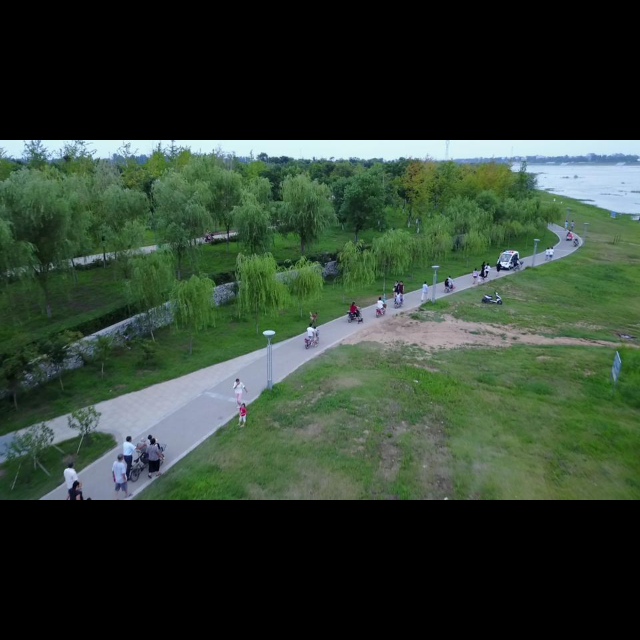

In [11]:
# check a single image to ensure letterboxing worked as expected
img = val_dataset[13,:,:,:].astype('uint8')
pilimg = Image.fromarray(img)
display(pilimg)

In [12]:
def detections_batch_generation(dataset, dataset_id, images_dict, sdk_type='optimized'):
    batch_dets = run_inference(runner=runner, sdk_type=sdk_type, input_data=dataset)
    all_dets = []
    for idx, output in enumerate(batch_dets):
        imgid = dataset_id[idx]
        
        # postprocessing steps
        # remove zero padding
        output = output.reshape(1,1,5,100) # expects a batch
        detections = remove_zero_padding(output, imgid)

        if detections.shape[0] == 0:
            print(f"No detections found for image: {int(imgid[0])}\n")
            continue
        # convert to xyxy and denormalise
        yxyx = np.full_like(detections, detections)
        xyxy = swap_columns(yxyx) # annoyingly, it is in yx, ont xy, what misery
        dets_scaled = rescale_bbox(xyxy, 640, 640)

        # get metadata to remove letterbox and rescale back to original size
        w,h, name, lb_scale, lb_pad_top, lb_pad_left = get_image_metadata(image_rescale_metadata, imgid)

        # reverse letterboxing and convert to xywh
        xyxy_orig = reverse_rescale_bboxes(dets_scaled[:, :4],lb_scale, lb_pad_top, lb_pad_left, (h,w))
        dets_scaled[:, :4] = ltxy2xywh(np.array(xyxy_orig))
        all_dets.append(dets_scaled)
        
    return(all_dets)


def batch_detections_to_json(batch):
    class_remap = {0: 1, 1: 2}
    res = []
    annId = 1
    for detections in batch:
        for el in detections:
            x,y,w,h,conf,classid,imgid = el
            imgid = int(imgid)
            res.append({"image_id": imgid, "category_id": class_remap[classid], "bbox": [x,y,w,h], "score": conf, "id": annId, "segmentation": []}) 
            annId +=1
    return res


def save_json_file(filename, data):
    with open(outputfile, 'w') as outf:
        json.dump(data, outf)
        outf.close()

    print(f"Total of {len(data)} annotations saved to {outputfile}")
    
def get_annotations_dict():
    result = {
        "bbox": [x_min, y_min, x_max, y_max],  # Bounding box in pixel coordinates
        "score": score,  # Confidence score of the detection
        "category_id": class_id,  # Class ID of the detected object
        "label": label_dictionary.get(str(class_id), f"class_{class_id}"),  # Class label or fallback
    }
    return result

In [13]:
quant_model_har_path

'yolov5sp2_ghost_visdrone_singlecls_quant_model.har'

In [14]:
batch_detections = detections_batch_generation(val_dataset, val_imageids, images)
processed_outputs = batch_detections_to_json(batch_detections)
variation = quant_model_har_path.split(".")[0]
# variation = fp_model_har_path.split(".")[0]
outputfile = f"/local/shared_with_docker/visdrone/detections_{variation}.json" 
save_json_file(outputfile, processed_outputs)

2025-05-05 02:24:34.067061: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 02:24:34.080289: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-05 02:24:34.080386: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

[info] Using 1 GPU for inference


Inference: 0entries [00:00, ?entries/s]2025-05-05 02:24:35.663271: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2025-05-05 02:24:44.792984: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8906
2025-05-05 02:24:44.976383: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
Inference: 536entries [00:11, 47.61entries/s] 


Total of 52352 annotations saved to /local/shared_with_docker/visdrone/detections_yolov5sp2_ghost_visdrone_singlecls_quant_model.json


#### Plot annotations on a single image

In [15]:
import cv2
import os
import json
import warnings

def xywh2xyxy(xywh):
    x,y,w,h = xywh
    x1 = x
    y1 = y
    x2 = x + w
    y2 = y + h

    return x1, y1, x2, y2

def xywhn2xyxy(xywh):
    x,y,w,h = xywh
    x1 = x - w / 2
    y1 = y - h / 2
    x2 = x + w / 2
    y2 = y + h / 2

    return x1, y1, x2, y2

def x1y1whn2xcywh(xywh):
    x,y,w,h = xywh
    x1 = x - w / 2
    y1 = y - h / 2


    return x1, y1, w, h

def get_annotations(annotations_path, img_id):
    with open(annotations_path, 'r') as file:
        gt_data = json.load(file)
        file.close()
    annotations = gt_data['annotations']
    images = gt_data['images']
    gt = []
    for ann in annotations:
        if ann['image_id'] == img_id:
            gt.append([ann['category_id'], *ann['bbox']])
    for img in images:
        if img['id'] == img_id:
            file_name = img['file_name']
    return gt, file_name

def get_detections(results_path, img_id=None):
    with open(results_path, 'r') as file:
        results = json.load(file)
        file.close()
    preds = []
    for res in results:
        if img_id is not None:
            if res['image_id'] != img_id:
                continue
        img_id = res['image_id']
        preds.append([res['category_id'], *res['bbox'], res['score'], img_id])
        assert img_id is not None, f"Image ID has not been found in {results}"
    return preds

def plot_annotations(image, predictions, color_map, label_map, gt=False):
    for idx, labels in enumerate(predictions):
        # Unpack the labels
        if gt:
            clsid, x1, y1, w, h = labels
            conf = 1
        else:
            clsid, x1, y1, w, h, conf, _ = labels
            
        x1, y1, x2, y2 = xywh2xyxy([x1, y1, w, h])
        x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
        
        if clsid not in [1,2]:
            warnings.warn(f"Class id {clsid} has been found in dataset")
            continue

        
        # Filter by confidence threshold
        if conf > 0.2:
            # Select color based on class
            color = color_map[clsid]  # Default to white if unknown class

            # Draw bounding box
            cv2.rectangle(img, (x1, y1), (x2, y2), color, thickness)

            # Display class name and confidence
            text = f"{label_map[clsid]}: {conf:.2f}"
            cv2.putText(img, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1, cv2.LINE_AA)
    return img



reading image at /local/shared_with_docker/visdrone/VisDrone2019-DET-val/images/0000001_05999_d_0000011.jpg...




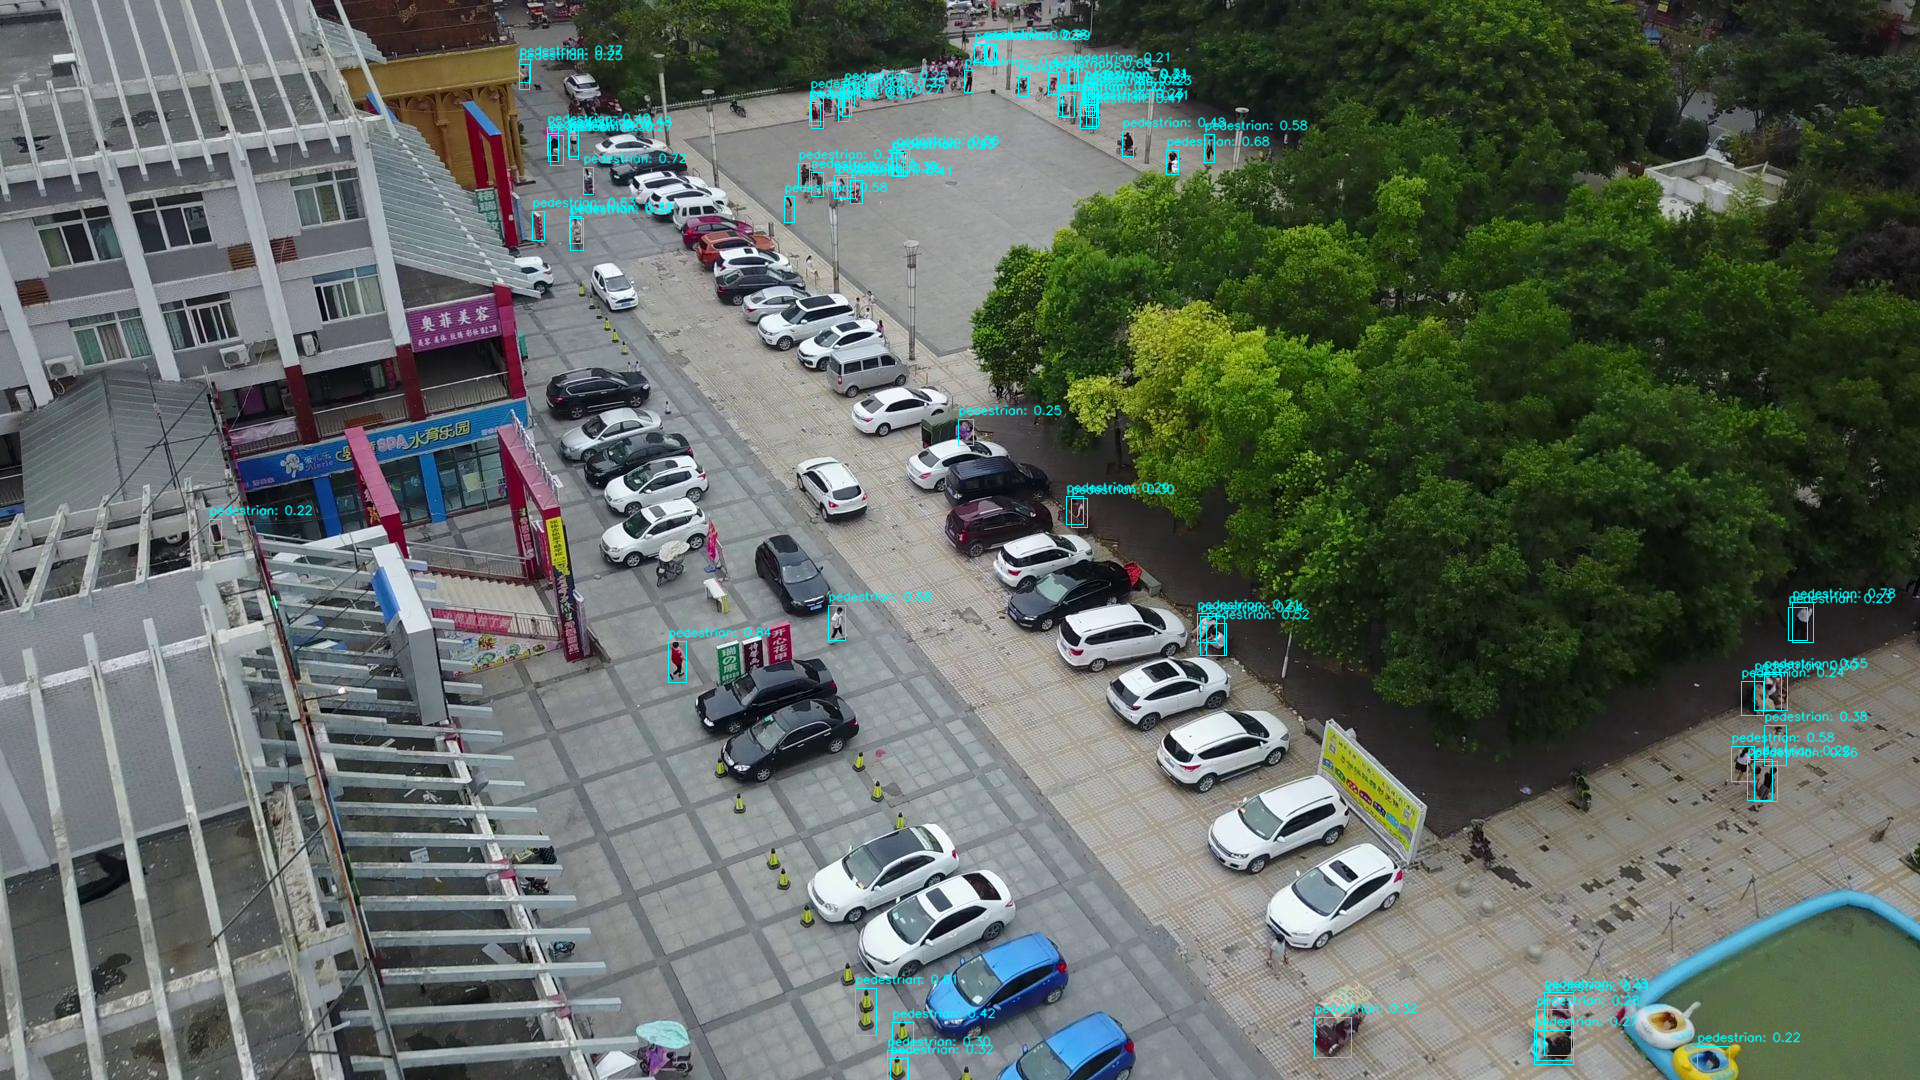

In [16]:
annotations_path = "/local/shared_with_docker/visdrone/annotations_VisDroneHumans_val.json"
results_path = outputfile
images_dir = "/local/shared_with_docker/visdrone/VisDrone2019-DET-val/images"


img_id = 8 # known imageid as per the dataset
gt, file_name = get_annotations(annotations_path, img_id=img_id)
detections = get_detections(results_path, img_id=img_id)

# Load the image
imagefilename = file_name 
imgpth = os.path.join(images_dir, imagefilename)
print(f"\n\nreading image at {imgpth}...\n\n")
img = cv2.imread(imgpth)
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

img_name = os.path.basename(imgpth).split('.')[0]

colorgt = {
    1: (66, 75, 245),
    2: (36, 45, 215)
}

thickness = 1

class_colors = {
    1: (0, 251, 255),  # Cyan
    2: (255, 201, 205)  # pinkish
}

class_names = {
    1: 'pedestrian',
    2: 'person'
}

img = plot_annotations(img, detections, class_colors, class_names)
# img = plot_annotations(img, gt, colorgt, class_names, gt=True)


pilimg = Image.fromarray(img)
display(pilimg)

In [17]:
# need to add an annotation ID and segmentation to json output from ultralytics to compare with original model
def map_imageid_to_json(detection_file, yolo5=False):
    with open(detection_file, 'r') as f:
        annotations = json.load(f)
        f.close()


    # Create a mapping from images using file_name as key and image_id as value
    mapping = {item["file_name"].split('.')[0]: item["id"] for item in images}

    # Update predictions dict by mapping image_id
    for item in annotations:
        item["image_id"] = mapping.get(item["image_id"], item["image_id"])
        
        if yolo5:
            if item["category_id"]==0:
                item["category_id"]=1
        
    return annotations

        
preds_file = '/local/shared_with_docker/visdrone/yolov5n_exp13_best_preds.json'
remapped_file = map_imageid_to_json(preds_file, yolo5=True)
with open("/local/shared_with_docker/visdrone/yolov5n_exp13_best_preds_ul.json", 'w') as f:
    json.dump(remapped_file, f)
    f.close()



In [18]:

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import pylab

import json
import os

pylab.rcParams['figure.figsize'] = (10.0, 8.0)

annType = ['segm','bbox','keypoints']
annType = annType[1]      #specify type here
prefix = 'person_keypoints' if annType=='keypoints' else 'instances'
print('Running demo for *%s* results.'%(annType))

#initialize COCO ground truth api
rootdir = '/local/shared_with_docker/visdrone/'
annFile = os.path.join(rootdir, 'annotations_VisDroneHumans_val.json')
cocoGt=COCO(annFile)

#initialize COCO detections api
# resFile= os.path.join(rootdir, 'detections_exp_5_yolo5n_dev_quant_model.json')
resFile = outputfile
cocoDt=cocoGt.loadRes(resFile)

imgIds=sorted(cocoGt.getImgIds())
imgIds = imgIds[0:]
catIDs = [1,2] # 81 for all IDs
useCats = 0
maxDets = [1, 10, 100]


# running evaluation
cocoEval = COCOeval(cocoGt,cocoDt,annType)
cocoEval.params.imgIds  = imgIds
cocoEval.params.catIds = catIDs
cocoEval.params.maxDets = maxDets
cocoEval.params.useCats = useCats
cocoEval.evaluate()
cocoEval.accumulate()
cocoEval.summarize()


Running demo for *bbox* results.
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.08s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=7.70s).
Accumulating evaluation results...
DONE (t=0.20s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.193
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.510
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.095
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.177
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.317
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.189
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.019
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.136
 Average Recall     (AR) @[ IoU=

In [ ]:
stats = cocoEval.stats

In [ ]:
stats

In [ ]:
import os
import json
import csv
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# Configs
annType = 'bbox'  # change to 'segm' or 'keypoints' if needed
rootdir = '/local/shared_with_docker/visdrone/'
annFile = os.path.join(rootdir, 'annotations_VisDroneHumans_val.json')
detections_dir = os.path.join(rootdir, 'model_eval')  # where all your detection JSONs are
output_csv = os.path.join(rootdir, 'evaluation_results.csv')

# Get list of detection files (adjust pattern if needed)
detection_files = [f for f in os.listdir(detections_dir) if f.endswith('.json') and 'detections' in f]

# Load ground truth
cocoGt = COCO(annFile)

# Prepare CSV output
headers = [
    'File', 'AP', 'AP50', 'AP75', 'AP_small', 'AP_medium', 'AP_large',
    'AR_1', 'AR_10', 'AR_100', 'AR_small', 'AR_medium', 'AR_large'
]
rows = []

# Loop through detection files and evaluate
for det_file in detection_files:
    print(f"Evaluating: {det_file}")
    resFile = os.path.join(detections_dir, det_file)
    cocoDt = cocoGt.loadRes(resFile)

    imgIds = sorted(cocoGt.getImgIds())
    catIDs = [1, 2]  # adjust as needed
    maxDets = [1, 10, 100]

    cocoEval = COCOeval(cocoGt, cocoDt, annType)
    cocoEval.params.imgIds = imgIds
    cocoEval.params.catIds = catIDs
    cocoEval.params.maxDets = maxDets
    cocoEval.params.useCats = 0
    cocoEval.evaluate()
    cocoEval.accumulate()
    cocoEval.summarize()

    # Redirect summarize output to variables
    stats = cocoEval.stats  # 12 metrics

    # Save to CSV row
    rows.append([det_file] + list(stats))
    print(list(stats))

# Write CSV
with open(output_csv, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(headers)
    writer.writerows(rows)

print(f"Done! Results saved to: {output_csv}")


In [ ]:
def generate_output_grids_np(height, width, strides=[8,16,32]):
    """
    Generate a numpy array containing grid coordinates and strides for a given height and width.

    Args:
        height (int): The height of the image.
        width (int): The width of the image.

    Returns:
        np.ndarray: A numpy array containing grid coordinates and strides.
    """

    all_coordinates = []

    for stride in strides:
        # Calculate the grid height and width
        grid_height = height // stride
        grid_width = width // stride

        # Generate grid coordinates
        g1, g0 = np.meshgrid(np.arange(grid_height), np.arange(grid_width), indexing='ij')

        # Create an array of strides
        s = np.full((grid_height, grid_width), stride)

        # Stack the coordinates along with the stride
        coordinates = np.stack((g0.flatten(), g1.flatten(), s.flatten()), axis=-1)

        # Append to the list
        all_coordinates.append(coordinates)

    # Concatenate all arrays in the list along the first dimension
    output_grids = np.concatenate(all_coordinates, axis=0)

    return output_grids

def calculate_boxes_and_probs(model_output:np.ndarray, output_grids:np.ndarray) -> np.ndarray:
    """
    Calculate the bounding boxes and their probabilities.

    Parameters:
    model_output (numpy.ndarray): The output of the model.
    output_grids (numpy.ndarray): The output grids.

    Returns:
    numpy.ndarray: The array containing the bounding box coordinates, class labels, and maximum probabilities.
    """
    # Calculate the bounding box coordinates
    box_centroids = (model_output[..., :2] + output_grids[..., :2]) * output_grids[..., 2:]
    box_sizes = np.exp(model_output[..., 2:4]) * output_grids[..., 2:]

    x0, y0 = [t.squeeze(axis=2) for t in np.split(box_centroids - box_sizes / 2, 2, axis=2)]
    w, h = [t.squeeze(axis=2) for t in np.split(box_sizes, 2, axis=2)]

    # Calculate the probabilities for each class
    box_objectness = model_output[..., 4]
    box_cls_scores = model_output[..., 5:]
    box_probs = np.expand_dims(box_objectness, -1) * box_cls_scores

    # Get the maximum probability and corresponding class for each proposal
    max_probs = np.max(box_probs, axis=-1)
    labels = np.argmax(box_probs, axis=-1)

    return np.array([x0, y0, w, h, labels, max_probs]).transpose((1, 2, 0))

def process_outputs(outputs:np.ndarray, input_dims:tuple, bbox_conf_thresh:float):

    """
    Process the model outputs to generate bounding box proposals filtered by confidence threshold.
    
    Parameters:
    - outputs (numpy.ndarray): The raw output from the model, which will be processed to calculate boxes and probabilities.
    - input_dims (tuple of int): Dimensions (height, width) of the input image to the model.
    - bbox_conf_thresh (float): Threshold for the bounding box confidence/probability. Bounding boxes with a confidence
                                score below this threshold will be discarded.
    
    Returns:
    - numpy.array: An array of proposals where each proposal is an array containing bounding box coordinates
                   and its associated probability, sorted in descending order by probability.
    """

    # Process the model output
    outputs = calculate_boxes_and_probs(outputs, generate_output_grids_np(*input_dims))
    # Filter the proposals based on the confidence threshold
    max_probs = outputs[:, :, -1]
    mask = max_probs > bbox_conf_thresh
    proposals = outputs[mask]
    # Sort the proposals by probability in descending order
    proposals = proposals[proposals[..., -1].argsort()][::-1]
    return proposals


def calc_iou(proposals:np.ndarray) -> np.ndarray:
    """
    Calculates the Intersection over Union (IoU) for all pairs of bounding boxes (x,y,w,h) in 'proposals'.

    The IoU is a measure of overlap between two bounding boxes. It is calculated as the area of
    intersection divided by the area of union of the two boxes.

    Parameters:
    proposals (2D np.array): A NumPy array of bounding boxes, where each box is an array [x, y, width, height].

    Returns:
    iou (2D np.array): The IoU matrix where each element i,j represents the IoU of boxes i and j.
    """

    # Calculate coordinates for the intersection rectangles
    x1 = np.maximum(proposals[:, 0], proposals[:, 0][:, None])
    y1 = np.maximum(proposals[:, 1], proposals[:, 1][:, None])
    x2 = np.minimum(proposals[:, 0] + proposals[:, 2], (proposals[:, 0] + proposals[:, 2])[:, None])
    y2 = np.minimum(proposals[:, 1] + proposals[:, 3], (proposals[:, 1] + proposals[:, 3])[:, None])
    
    # Calculate intersection areas
    intersections = np.maximum(x2 - x1, 0) * np.maximum(y2 - y1, 0)

    # Calculate union areas
    areas = proposals[:, 2] * proposals[:, 3]
    unions = areas[:, None] + areas - intersections

    # Calculate IoUs
    iou = intersections / unions

    # Return the iou matrix
    return iou


def nms_sorted_boxes(iou:np.ndarray, iou_thresh:float=0.45) -> np.ndarray:
    """
    Applies non-maximum suppression (NMS) to sorted bounding boxes.

    It suppresses boxes that have high overlap (as defined by the IoU threshold) with a box that 
    has a higher score.

    Parameters:
    iou (np.ndarray): An IoU matrix where each element i,j represents the IoU of boxes i and j.
    iou_thresh (float): The IoU threshold for suppression. Boxes with IoU > iou_thresh are suppressed.

    Returns:
    keep (np.ndarray): The indices of the boxes to keep after applying NMS.
    """

    # Create a boolean mask to keep track of boxes
    mask = np.ones(iou.shape[0], dtype=bool)

    # Apply non-max suppression
    for i in range(iou.shape[0]):
        if mask[i]:
            # Suppress boxes with higher index and IoU > threshold
            mask[(iou[i] > iou_thresh) & (np.arange(iou.shape[0]) > i)] = False

    # Return the indices of the boxes to keep
    return np.arange(iou.shape[0])[mask]

In [ ]:
outputs = batch_dets[0][3]

# Process the model output to get object proposals
proposals = process_outputs(outputs, (640,640), 0.2)

# Apply non-max suppression to filter overlapping proposals
proposal_indices = nms_sorted_boxes(calc_iou(proposals[:, :-2]), iou_thresh)
proposals = proposals[proposal_indices]

In [ ]:
#    val_dataset, val_imageids, images
# batch_dets = run_inference(runner=runner, sdk_type='native', input_data=val_dataset)
output_array = outputs[0].reshape(-1)
outputs.shape


## Compile

In [19]:
# quant_model_har_path = 'best_fp_model.har'
# runner = ClientRunner(har=fp_opt_model_har_path, hw_arch=chosen_hw_arch)
# hef_model_name = fp_opt_model_har_path.replace(".har", ".hef")

runner = ClientRunner(har=quant_model_har_path, hw_arch=chosen_hw_arch)
hef_model_name = quant_model_har_path.replace(".har", ".hef")
print(f"compiling har model from {quant_model_har_path}\nto {hef_model_name}\nhardware arch: {chosen_hw_arch}")
hef = runner.compile()


compiling har model from yolov5sp2_ghost_visdrone_singlecls_quant_model.har
to yolov5sp2_ghost_visdrone_singlecls_quant_model.hef
hardware arch: hailo8l
[info] Loading network parameters
[info] Starting Hailo allocation and compilation flow
[info] Adding an output layer after conv41
[info] Adding an output layer after conv48
[info] Adding an output layer after conv54
[info] Finding the best partition to contexts...
[info] Iteration #1 - Contexts: 3
[info] Iteration #1 - Contexts: 3,
[info] Iteration #2 - Contexts: 3
[info] Iteration #2 - Contexts: 3,
[info] Iteration #3 - Contexts: 3
[info] Iteration #3 - Contexts: 3,
[info] Iteration #4 - Contexts: 3
[info] Iteration #4 - Contexts: 3,
[info] Iteration #5 - Contexts: 3
[info] Iteration #5 - Contexts: 3,
[info] Iteration #6 - Contexts: 3
[info] Iteration #6 - Contexts: 3,
[info] Iteration #7 - Contexts: 3
[info] Iteration #7 - Contexts: 3,
[info] Iteration #8 - Contexts: 3
[info] Iteration #8 - Contexts: 3,
[info] Iteration #9 - Context

[info] Iteration #111 - Contexts: 4
[info] Iteration #111 - Contexts: 4,
[info] Iteration #112 - Contexts: 4
[info] Iteration #112 - Contexts: 4,
[info] Iteration #113 - Contexts: 4
[info] Iteration #113 - Contexts: 4,
[info] Iteration #114 - Contexts: 4
[info] Iteration #114 - Contexts: 4,
[info] Iteration #115 - Contexts: 4
[info] Iteration #115 - Contexts: 4,
[info] Iteration #116 - Contexts: 4
[info] Iteration #116 - Contexts: 4,
[info] Iteration #117 - Contexts: 4
[info] Iteration #117 - Contexts: 4,
[info] Iteration #118 - Contexts: 4
[info] Iteration #118 - Contexts: 4,
[info] Iteration #119 - Contexts: 4
[info] Iteration #119 - Contexts: 4,
[info] Iteration #120 - Contexts: 4
[info] Iteration #120 - Contexts: 4,
[info] Iteration #121 - Contexts: 4
[info] Iteration #121 - Contexts: 4,
[info] Iteration #122 - Contexts: 4
[info] Iteration #122 - Contexts: 4,
[info] Iteration #123 - Contexts: 4
[info] Iteration #123 - Contexts: 4,
[info] Iteration #124 - Contexts: 4
[info] Iteratio

[info] Iteration #225 - Contexts: 5
[info] Iteration #225 - Contexts: 5,
[info] Iteration #226 - Contexts: 5
[info] Iteration #226 - Contexts: 5,
[info] Iteration #227 - Contexts: 5
[info] Iteration #227 - Contexts: 5,
[info] Iteration #228 - Contexts: 5
[info] Iteration #228 - Contexts: 5,
[info] Iteration #229 - Contexts: 5
[info] Iteration #229 - Contexts: 5,
[info] Iteration #230 - Contexts: 5
[info] Iteration #230 - Contexts: 5,
[info] Iteration #231 - Contexts: 5
[info] Iteration #231 - Contexts: 5,
[info] Iteration #232 - Contexts: 5
[info] Iteration #232 - Contexts: 5,
[info] Iteration #233 - Contexts: 5
[info] Iteration #233 - Contexts: 5,
[info] Iteration #234 - Contexts: 5
[info] Iteration #234 - Contexts: 5,
[info] Iteration #235 - Contexts: 5
[info] Iteration #235 - Contexts: 5,
[info] Iteration #236 - Contexts: 5
[info] Iteration #236 - Contexts: 5,
[info] Iteration #237 - Contexts: 5
[info] Iteration #237 - Contexts: 5,
[info] Iteration #238 - Contexts: 5
[info] Iteratio

[info] Context:0/2 Iteration 4: Trying parallel mapping...  
          cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  cluster_6  cluster_7  prepost 
 worker0  *          *          *          *          *          *          *          *          V       
 worker1  *          *          *          *          *          *          *          *          V       
 worker2  *          *          *          *          *          *          *          *          V       
 worker3                                                                                                  

  00:00
[info] Context:0/2 Iteration 4: Trying parallel mapping...  
          cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  cluster_6  cluster_7  prepost 
 worker0  *          *          *          *          *          *          *          *          V       
 worker1  *          *          *          *          *          *          *          *          V       
 worker2  *  

[info] Context:0/2 Iteration 4: Trying parallel mapping...  
          cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  cluster_6  cluster_7  prepost 
 worker0  V          V          *          *          V          V          *          *          V       
 worker1  V          V          *          *          V          V          *          *          V       
 worker2  V          V          *          *          V          V          *          *          V       
 worker3                                                                                                  

  00:00
[info] Context:0/2 Iteration 4: Trying parallel mapping...  
          cluster_0  cluster_1  cluster_2  cluster_3  cluster_4  cluster_5  cluster_6  cluster_7  prepost 
 worker0  V          V          *          *          V          V          *          *          V       
 worker1  V          V          *          *          V          V          *          *          V       
 worker2  V  

...

[info] Iteration #157 - Contexts: 5
[info] Iteration #157 - Contexts: 5,
[info] Iteration #158 - Contexts: 5
[info] Iteration #158 - Contexts: 5,
[info] Iteration #159 - Contexts: 5
[info] Iteration #159 - Contexts: 5,
[info] Iteration #160 - Contexts: 5
[info] Iteration #160 - Contexts: 5,
[info] Iteration #161 - Contexts: 5
[info] Iteration #161 - Contexts: 5,
[info] Iteration #162 - Contexts: 5
[info] Iteration #162 - Contexts: 5,
[info] Iteration #163 - Contexts: 5
[info] Iteration #163 - Contexts: 5,
[info] Iteration #164 - Contexts: 5
[info] Iteration #164 - Contexts: 5,
[info] Iteration #165 - Contexts: 5
[info] Iteration #165 - Contexts: 5,
[info] Iteration #166 - Contexts: 5
[info] Iteration #166 - Contexts: 5,
[info] Iteration #167 - Contexts: 5
[info] Iteration #167 - Contexts: 5,
[info] Iteration #168 - Contexts: 5
[info] Iteration #168 - Contexts: 5,
[info] Iteration #169 - Contexts: 5
[info] Iteration #169 - Contexts: 5,
[info] Iteration #170 - Contexts: 5
[info] Iteratio

[info] Iteration #271 - Contexts: 6
[info] Iteration #271 - Contexts: 6,
[info] Iteration #272 - Contexts: 6
[info] Iteration #272 - Contexts: 6,
[info] Iteration #273 - Contexts: 6
[info] Iteration #273 - Contexts: 6,
[info] Iteration #274 - Contexts: 6
[info] Iteration #274 - Contexts: 6,
[info] Iteration #275 - Contexts: 6
[info] Iteration #275 - Contexts: 6,
[info] Iteration #276 - Contexts: 6
[info] Iteration #276 - Contexts: 6,
[info] Iteration #277 - Contexts: 6
[info] Iteration #277 - Contexts: 6,
[info] Iteration #278 - Contexts: 6
[info] Iteration #278 - Contexts: 6,
[info] Iteration #279 - Contexts: 6
[info] Iteration #279 - Contexts: 6,
[info] Iteration #280 - Contexts: 6
[info] Iteration #280 - Contexts: 6,
[info] Iteration #281 - Contexts: 6
[info] Iteration #281 - Contexts: 6,
[info] Iteration #282 - Contexts: 6
[info] Iteration #282 - Contexts: 6,
[info] Iteration #283 - Contexts: 6
[info] Iteration #283 - Contexts: 6,
[info] Iteration #284 - Contexts: 6
[info] Iteratio

[info] Iteration #52 - Contexts: 4
[info] Iteration #52 - Contexts: 4,
[info] Iteration #53 - Contexts: 4
[info] Iteration #53 - Contexts: 4,
[info] Iteration #54 - Contexts: 4
[info] Iteration #54 - Contexts: 4,
[info] Iteration #55 - Contexts: 4
[info] Iteration #55 - Contexts: 4,
[info] Iteration #56 - Contexts: 4
[info] Iteration #56 - Contexts: 4,
[info] Iteration #57 - Contexts: 4
[info] Iteration #57 - Contexts: 4,
[info] Iteration #58 - Contexts: 4
[info] Iteration #58 - Contexts: 4,
[info] Iteration #59 - Contexts: 4
[info] Iteration #59 - Contexts: 4,
[info] Iteration #60 - Contexts: 4
[info] Iteration #60 - Contexts: 4,
[info] Iteration #61 - Contexts: 4
[info] Iteration #61 - Contexts: 4,
[info] Iteration #62 - Contexts: 4
[info] Iteration #62 - Contexts: 4,
[info] Iteration #63 - Contexts: 4
[info] Iteration #63 - Contexts: 4,
[info] Iteration #64 - Contexts: 4
[info] Iteration #64 - Contexts: 4,
[info] Iteration #65 - Contexts: 4
[info] Iteration #65 - Contexts: 4,
[info]

[info] Iteration #166 - Contexts: 6
[info] Iteration #166 - Contexts: 6,
[info] Iteration #167 - Contexts: 6
[info] Iteration #167 - Contexts: 6,
[info] Iteration #168 - Contexts: 6
[info] Iteration #168 - Contexts: 6,
[info] Iteration #169 - Contexts: 6
[info] Iteration #169 - Contexts: 6,
[info] Iteration #170 - Contexts: 6
[info] Iteration #170 - Contexts: 6,
[info] Iteration #171 - Contexts: 6
[info] Iteration #171 - Contexts: 6,
[info] Iteration #172 - Contexts: 6
[info] Iteration #172 - Contexts: 6,
[info] Iteration #173 - Contexts: 6
[info] Iteration #173 - Contexts: 6,
[info] Iteration #174 - Contexts: 6
[info] Iteration #174 - Contexts: 6,
[info] Iteration #175 - Contexts: 6
[info] Iteration #175 - Contexts: 6,
[info] Iteration #176 - Contexts: 6
[info] Iteration #176 - Contexts: 6,
[info] Iteration #177 - Contexts: 6
[info] Iteration #177 - Contexts: 6,
[info] Iteration #178 - Contexts: 6
[info] Iteration #178 - Contexts: 6,
[info] Iteration #179 - Contexts: 6
[info] Iteratio

[info] Iteration #280 - Contexts: 7
[info] Iteration #280 - Contexts: 7,
[info] Iteration #281 - Contexts: 7
[info] Iteration #281 - Contexts: 7,
[info] Iteration #282 - Contexts: 7
[info] Iteration #282 - Contexts: 7,
[info] Iteration #283 - Contexts: 7
[info] Iteration #283 - Contexts: 7,
[info] Iteration #284 - Contexts: 7
[info] Iteration #284 - Contexts: 7,
[info] Iteration #285 - Contexts: 7
[info] Iteration #285 - Contexts: 7,
[info] Iteration #286 - Contexts: 7
[info] Iteration #286 - Contexts: 7,
[info] Iteration #287 - Contexts: 7
[info] Iteration #287 - Contexts: 7,
[info] Iteration #288 - Contexts: 7
[info] Iteration #288 - Contexts: 7,
[info] Iteration #289 - Contexts: 7
[info] Iteration #289 - Contexts: 7,
[info] Iteration #290 - Contexts: 7
[info] Iteration #290 - Contexts: 7,
[info] Iteration #291 - Contexts: 7
[info] Iteration #291 - Contexts: 7,
[info] Iteration #292 - Contexts: 7
[info] Iteration #292 - Contexts: 7,
[info] Iteration #293 - Contexts: 7
[info] Iteratio

In [20]:
with open(hef_model_name, "wb") as f:
    f.write(hef)
    
!cp {hef_model_name} /local/shared_with_docker/visdrone/models/best/hef/{hef_model_name}

In [21]:
!cp {quant_model_har_path} /local/shared_with_docker/visdrone/models/best/har/{quant_model_har_path}


## Redundant functions and code
This was used for single image inference, e.g. for iterating over each image

In [ ]:
# these functions are used for single image evaluation
# intented for use when iterating over the dataset
def get_input_data(image_dataset, image_id):
    assert image_id >0, f"Image id should be >0 as per coco formatting"

    imgname, imgid = image_dataset[image_id-1]
    imgfile = os.path.join(images_path, imgname)
    print(f"opening image at {imgfile}")
    img = Image.open(imgfile).convert('RGB')
    img_preproc = preproc(img)
    img_input = img_preproc.reshape(1,640,640,3)
    
    return img_input, imgid, img

def get_single_image(image_rootpath, image_file):
    imgfile = os.path.join(image_rootpath, imgname)
    print(f"opening image at {imgfile}")
    img = Image.open(imgfile).convert('RGB')
    img_preproc = preproc(img)
    img_input = img_preproc.reshape(1,640,640,3)
    
    return img_input, img

def detections_to_json(detections):
    class_remap = {0: 1, 1: 2}
    res = []
    annId = 1
    for el in detections:
        x,y,w,h,conf,classid,imgid = el
        imgid = int(imgid)
        res.append({"image_id": imgid, "category_id": class_remap[classid], "bbox": [x,y,w,h], "score": conf, "id": annId, "segmentation": []}) 
        annId +=1
    return res

def get_single_image(image_rootpath, image_file):
    imgfile = os.path.join(image_rootpath, image_file)
    print(f"opening image at {imgfile}")
    img = Image.open(imgfile).convert('RGB')
    img_preproc = preproc(img)
    img_input = img_preproc.reshape(1,640,640,3)
    
    return img_input, img

def generate_detections_file(image_list, image_dir):
    all_dets = []
    for idx, imgdata in enumerate(image_list):
        imgname, imgid = imgdata
        img_input, img = get_single_image(image_dir, imgname)
        
        output = run_inference(runner=runner, sdk_type='x', input_data=img_input)
        detections = remove_zero_padding(output, imgid)

        xywh = np.full_like(detections, detections)
        xywh = swap_columns(xywh) # annoyingly, it is in yx, ont xy, what misery
        xywh = ltxy2xywh(xywh) # convert x2/y2 to w/h


        w,h, name = get_image_metadata(images, imgid)

        dets_scaled = rescale_bbox(xywh, w, h)
        all_dets.append(dets_scaled)
    return(all_dets)
# full_data_dets = generate_detections_file(image_list, images_path)

    

# img_input, imgid, img = get_input_data(image_list, 1)
# output = run_inference(runner=runner, sdk_type='opt', input_data=img_input)
# detections = remove_zero_padding(output, imgid)

# xywh = np.full_like(detections, detections)
# xywh = swap_columns(xywh) # annoyingly, it is in yx, ont xy, what misery
# xywh = ltxy2xywh(xywh) # convert x2/y2 to w/h


# w,h, name = get_image_metadata(images, imgid)

# dets_scaled = rescale_bbox(xywh, w, h)

# processed_outputs = detections_to_json(dets_scaled)
# outputfile = f"/local/shared_with_docker/visdrone/detections_VisDrone_quant_dets.json" 
# with open(outputfile, 'w') as outf:
#     json.dump(processed_outputs, outf)
#     outf.close()
    
# print(f"Total of {len(processed_outputs)} annotations saved to {outputfile}")